# Persona Generation EDA: Full vs US-only

이 노트북은 #4 실험을 위해 전체 데이터 기준 persona generation 결과와 US-only 기준 persona generation 결과를 비교한다.

비교 대상:

- `data/interim/funnel_persona_gen/` : 전체 구매 유저 기준 generation 결과
- `data/interim/funnel_persona_gen_us/` : US 구매 유저 기준 generation 결과

주의:

- #4의 최종 분포 비교는 동일한 persona taxonomy로 labeling한 결과를 비교해야 한다.
- 여기서는 generation 산출물 자체의 차이를 EDA하여, 수동 정제 포인트와 country effect 가능성을 점검한다.

In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_rows', 200)
sns.set_theme(style='whitegrid')

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
RESULT_DIRS = {
    'Full': ROOT / 'data/interim/funnel_persona_gen',
    'US-only': ROOT / 'data/interim/funnel_persona_gen_us',
}

for label, path in RESULT_DIRS.items():
    print(label, path, path.exists())

Full /Users/leejungyeon/Workspace/projects/why-they-leave/retail-clickstream-analysis/data/interim/funnel_persona_gen True
US-only /Users/leejungyeon/Workspace/projects/why-they-leave/retail-clickstream-analysis/data/interim/funnel_persona_gen_us True


In [2]:
def clean_text(value):
    if value is None:
        return ''
    value = str(value)
    value = re.sub(r'\*+', '', value)
    value = value.replace('\u2011', '-').replace('\u2013', '-').replace('\u2014', '-')
    return re.sub(r'\s+', ' ', value).strip()


def load_stage(dataset, base_dir, file_name, stage):
    path = base_dir / file_name
    data = json.loads(path.read_text(encoding='utf-8'))
    rows = []
    if stage == 'final':
        for rank, p in enumerate(data, 1):
            rows.append({
                'dataset': dataset,
                'stage': stage,
                'iter': 0,
                'rank': rank,
                'name': clean_text(p.get('name')),
                'definition': clean_text(p.get('definition')),
            })
    else:
        for block in data:
            iter_id = block.get('iter')
            for rank, p in enumerate(block.get('personas', []), 1):
                rows.append({
                    'dataset': dataset,
                    'stage': stage,
                    'iter': iter_id,
                    'rank': rank,
                    'name': clean_text(p.get('name')),
                    'definition': clean_text(p.get('definition')),
                })
    return pd.DataFrame(rows)

frames = []
for dataset, base_dir in RESULT_DIRS.items():
    frames.append(load_stage(dataset, base_dir, 'step1_persona_sets.json', 'step1'))
    frames.append(load_stage(dataset, base_dir, 'step2_persona_sets.json', 'step2'))
    frames.append(load_stage(dataset, base_dir, 'final_personas.json', 'final'))

persona_df = pd.concat(frames, ignore_index=True)
persona_df['text'] = persona_df['name'] + ' ' + persona_df['definition']
persona_df.head()

,dataset,stage,iter,rank,name,definition,text
0,Full,step1,0,1,E-book Enthusiast,"Purchases multiple e-books, often in different categories.","E-book Enthusiast Purchases multiple e-books, often in different categories."
1,Full,step1,0,2,Frequent Puzzle Buyer,"Buys puzzles multiple times, often in different colors.","Frequent Puzzle Buyer Buys puzzles multiple times, often in different colors."
2,Full,step1,0,3,Water Bottle Collector,"Purchases water bottles in various colors, with high frequency.","Water Bottle Collector Purchases water bottles in various colors, with high frequency."
3,Full,step1,0,4,T-shirt Lover,Buys multiple t-shirts in different colors and styles.,T-shirt Lover Buys multiple t-shirts in different colors and styles.
4,Full,step1,0,5,Paperback Reader,"Frequently purchases paperbacks, often in bulk.","Paperback Reader Frequently purchases paperbacks, often in bulk."


In [3]:
summary = (
    persona_df.groupby(['dataset', 'stage'])
    .agg(
        rows=('name', 'size'),
        unique_names=('name', 'nunique'),
        avg_definition_len=('definition', lambda s: s.str.len().mean().round(1)),
    )
    .reset_index()
)
summary

,dataset,stage,rows,unique_names,avg_definition_len
0,Full,final,20,20,65.4
1,Full,step1,800,558,57.1
2,Full,step2,160,124,66.4
3,US-only,final,20,20,64.0
4,US-only,step1,800,579,57.0
5,US-only,step2,160,132,65.0


## Macro Group Mapping

LLM이 만든 persona 이름은 매번 조금씩 다르므로, 직접 exact name만 비교하면 구조가 잘 보이지 않는다. 아래 regex 기반 매크로 그룹으로 묶어 대략적인 주제 분포를 본다.

In [4]:
GROUP_PATTERNS = [
    ('Books', r'book|e-book|ebook|paperback|hardcover|reader|bookworm'),
    ('Beauty/Skincare', r'beauty|skincare|skin|haircare|lipstick|cosmetic|serum|moisturizer|sunscreen|shampoo|conditioner'),
    ('Fashion/Apparel', r'fashion|apparel|clothing|footwear|dress|t-shirt|shirt|hoodie|jeans|sneaker|sock|jacket'),
    ('Sports/Fitness', r'fitness|sport|wellness|outdoor|yoga|dumbbell|water bottle|cycling|helmet|tennis|gear'),
    ('Toys/Games', r'toy|kid|doll|action figure|building block|puzzle|game|board game'),
    ('Electronics/Tech', r'electronic|tech|gadget|webcam|smartwatch|ssd|monitor|keyboard|mouse|headphone|speaker'),
    ('Home/Kitchen', r'home|kitchen|appliance|coffee|blender|toaster|vacuum|cookware|lamp|decor'),
    ('Repeat/Single', r'repeat|repurchas|replenish|frequency|single|minimalist|specialist'),
    ('Mixed/General', r'diverse|mixed|variety|general|miscellaneous|assorted|unrelated'),
    ('Color Artifact', r'color|shade|colour'),
]


def assign_group(text):
    text = clean_text(text).lower()
    matches = [group for group, pattern in GROUP_PATTERNS if re.search(pattern, text)]
    return matches[0] if matches else 'Other'


def all_groups(text):
    text = clean_text(text).lower()
    matches = [group for group, pattern in GROUP_PATTERNS if re.search(pattern, text)]
    return matches or ['Other']

persona_df['macro_group'] = persona_df['text'].map(assign_group)
persona_df['all_groups'] = persona_df['text'].map(all_groups)
persona_df[['dataset', 'stage', 'name', 'macro_group', 'definition']].head(10)

,dataset,stage,name,macro_group,definition
0,Full,step1,E-book Enthusiast,Books,"Purchases multiple e-books, often in different categories."
1,Full,step1,Frequent Puzzle Buyer,Toys/Games,"Buys puzzles multiple times, often in different colors."
2,Full,step1,Water Bottle Collector,Sports/Fitness,"Purchases water bottles in various colors, with high frequency."
3,Full,step1,T-shirt Lover,Fashion/Apparel,Buys multiple t-shirts in different colors and styles.
4,Full,step1,Paperback Reader,Books,"Frequently purchases paperbacks, often in bulk."
5,Full,step1,Action Figure Collector,Toys/Games,"Buys multiple action figures, sometimes repeatedly."
6,Full,step1,Building Blocks Buyer,Toys/Games,Purchases building blocks in various colors and quantities.
7,Full,step1,Cosmetics Explorer,Beauty/Skincare,Buys lipsticks or moisturizers in diverse shades.
8,Full,step1,Hardcover Devotee,Books,"Frequently purchases hardcover books, sometimes multiple copies."
9,Full,step1,Yoga Mat User,Sports/Fitness,Buys yoga mats in different colors or repeatedly.


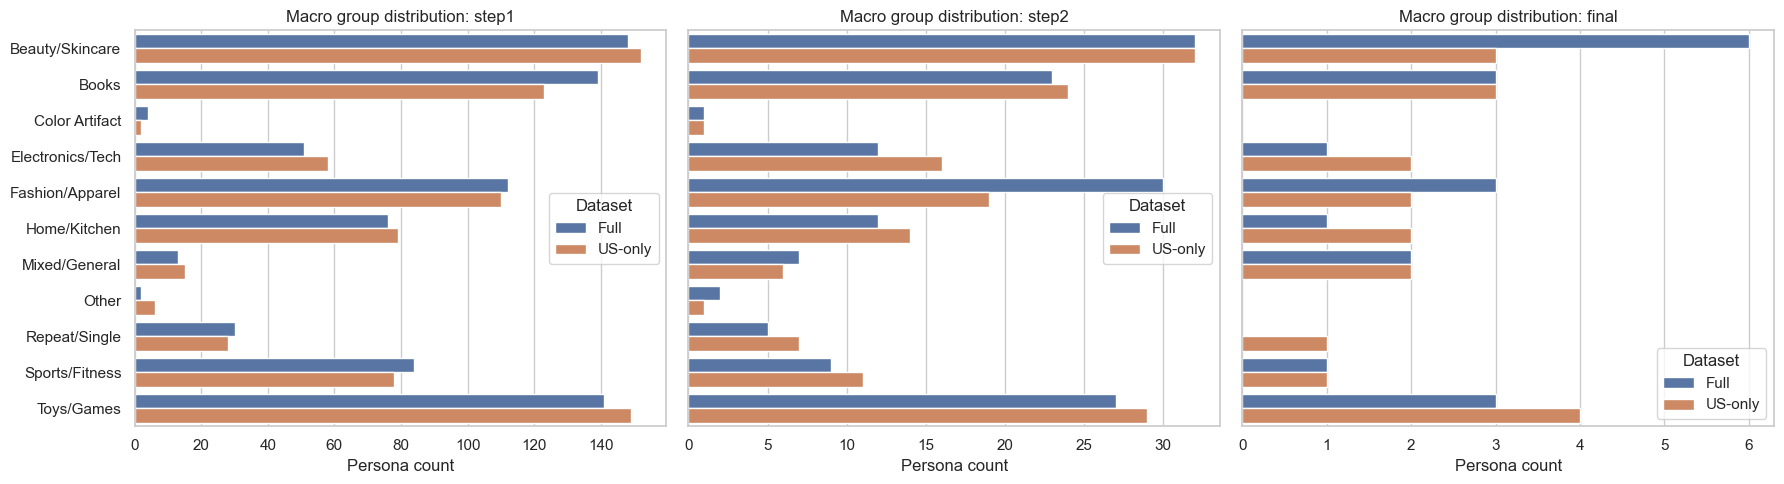

In [5]:
group_counts = (
    persona_df.groupby(['dataset', 'stage', 'macro_group'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
stages = ['step1', 'step2', 'final']
for ax, stage in zip(axes, stages):
    plot_df = group_counts[group_counts['stage'] == stage]
    sns.barplot(data=plot_df, x='count', y='macro_group', hue='dataset', ax=ax)
    ax.set_title(f'Macro group distribution: {stage}')
    ax.set_xlabel('Persona count')
    ax.set_ylabel('')
    ax.legend(title='Dataset')
plt.tight_layout()
plt.show()

In [6]:
final_df = persona_df[persona_df['stage'] == 'final'].copy()
final_table = final_df[['dataset', 'rank', 'name', 'macro_group', 'definition']].sort_values(['dataset', 'rank'])
final_table

,dataset,rank,name,macro_group,definition
960,Full,1,E-book Enthusiast,Books,Purchases multiple e-books (often in bulk or across genres) with minimal other products.
961,Full,2,Fitness Enthusiast,Fashion/Apparel,"Buys fitness gear (dumbbells, yoga mats, sneakers) and apparel for workouts."
962,Full,3,Beauty & Skincare Enthusiast,Beauty/Skincare,"Purchases 2+ beauty items (lipsticks, moisturizers, serums, shampoos)."
963,Full,4,Apparel & Footwear Buyer,Fashion/Apparel,"Buys clothing (hoodies, jeans, sneakers, dresses) and accessories."
964,Full,5,Home Appliance Shopper,Home/Kitchen,"Purchases kitchen or cleaning appliances (air fryers, vacuums, blenders)."
965,Full,6,Bookworm,Books,"Frequently buys e-books, hardcovers, or paperbacks (often in bulk)."
966,Full,7,Gadget & Tech User,Electronics/Tech,"Purchases electronics (monitors, mice, keyboards, webcams) for upgrades."
967,Full,8,Kid-Focused Shopper,Toys/Games,"Buys toys (dolls, action figures, building blocks) for children."
968,Full,9,Repetitive Purchaser,Beauty/Skincare,"Repurchases the same product (e.g., sneakers, moisturizers, water bottles)."
969,Full,10,Puzzle & Game Enthusiast,Toys/Games,"Purchases puzzles, board games, or building blocks."


## Final Persona Group Distribution

최종 20개 persona만 놓고 보면, 전체/US에서 어떤 주제가 과하게 중복되는지 빠르게 확인할 수 있다.

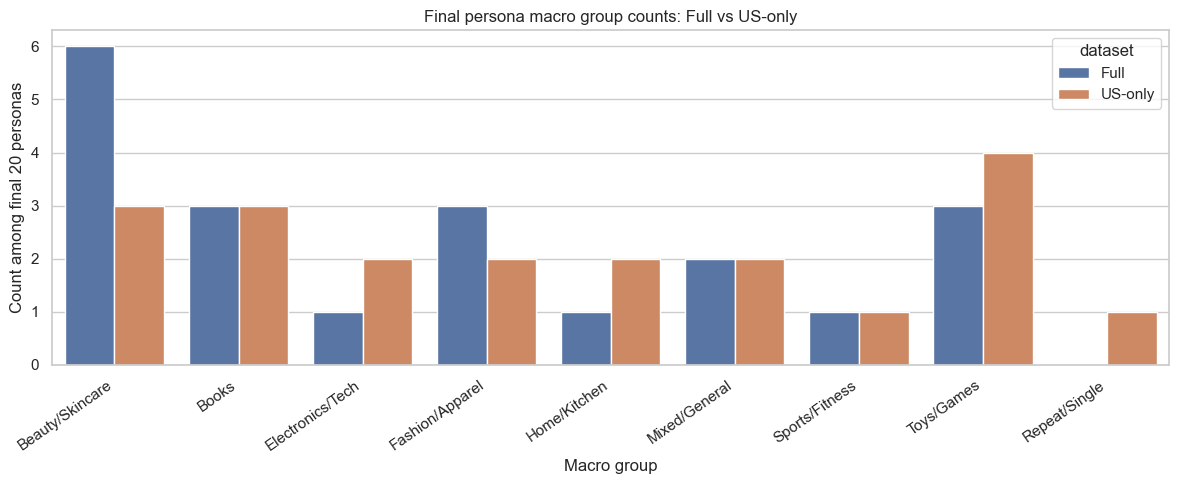

dataset,Full,US-only
macro_group,,
Beauty/Skincare,6,3
Books,3,3
Electronics/Tech,1,2
Fashion/Apparel,3,2
Home/Kitchen,1,2
Mixed/General,2,2
Repeat/Single,0,1
Sports/Fitness,1,1
Toys/Games,3,4


In [7]:
final_group = (
    final_df.groupby(['dataset', 'macro_group'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12, 5))
sns.barplot(data=final_group, x='macro_group', y='count', hue='dataset')
plt.xticks(rotation=35, ha='right')
plt.title('Final persona macro group counts: Full vs US-only')
plt.xlabel('Macro group')
plt.ylabel('Count among final 20 personas')
plt.tight_layout()
plt.show()

final_group.pivot(index='macro_group', columns='dataset', values='count').fillna(0).astype(int)

## Frequent Persona Themes Before Final Selection

Step 1/2에서 자주 등장한 persona 이름을 보면 LLM이 어떤 주제를 반복적으로 뽑는지 확인할 수 있다. 이름이 조금씩 다르므로 macro group도 함께 본다.

In [8]:
for dataset in ['Full', 'US-only']:
    for stage in ['step1', 'step2']:
        display_df = (
            persona_df[(persona_df['dataset'] == dataset) & (persona_df['stage'] == stage)]
            .groupby(['name', 'macro_group'])
            .size()
            .reset_index(name='freq')
            .sort_values(['freq', 'name'], ascending=[False, True])
            .head(15)
        )
        print(f'\n[{dataset} / {stage}] top repeated exact names')
        display(display_df)


[Full / step1] top repeated exact names


,name,macro_group,freq
176,E-book Enthusiast,Books,12
146,Doll Collector,Toys/Games,10
417,Paperback Reader,Books,10
6,Action Figure Collector,Toys/Games,8
217,Fitness Gear Collector,Sports/Fitness,7
317,Home Appliance Shopper,Home/Kitchen,7
434,Puzzle Solver,Toys/Games,7
8,Action Figure Fan,Toys/Games,6
34,Beauty Product User,Beauty/Skincare,6
221,Fitness Gear User,Sports/Fitness,6



[Full / step2] top repeated exact names


,name,macro_group,freq
44,E-book Enthusiast,Books,5
14,Book Collector,Books,3
36,Diversified General Shopper,Mixed/General,3
38,Doll & Toy Collector,Toys/Games,3
50,Fitness Enthusiast,Fashion/Apparel,3
76,Home Appliance Shopper,Home/Kitchen,3
79,Kid-Focused Shopper,Toys/Games,3
81,Kitchen & Home Appliance Buyer,Home/Kitchen,3
4,Apparel & Footwear Buyer,Fashion/Apparel,2
8,Beauty & Skincare User,Beauty/Skincare,2



[US-only / step1] top repeated exact names


,name,macro_group,freq
4,Action Figure Collector,Toys/Games,12
152,Doll Collector,Toys/Games,11
425,Paperback Reader,Books,10
182,E-book Enthusiast,Books,9
440,Puzzle Solver,Toys/Games,8
6,Action Figure Enthusiast,Toys/Games,7
185,E-book Reader,Books,7
208,Fitness Enthusiast,Sports/Fitness,6
478,Single-Item Buyer,Repeat/Single,6
27,Beauty Minimalist,Beauty/Skincare,5



[US-only / step2] top repeated exact names


,name,macro_group,freq
66,Frequent Repurchaser,Repeat/Single,3
1,Action Figure Collector,Toys/Games,2
2,Action Figure Enthusiast,Toys/Games,2
13,Book & Puzzle Lover,Books,2
14,Book Enthusiast,Books,2
17,Building Blocks Enthusiast,Toys/Games,2
31,Diverse Kitchenware Collector,Home/Kitchen,2
37,Doll Collector,Toys/Games,2
42,E-book Enthusiast,Books,2
45,Electronics & Tech Buyer,Electronics/Tech,2


## Full vs US-only Final Similarity

서로 다른 final taxonomy끼리 이름/정의 텍스트의 Jaccard similarity를 계산한다. 값이 높으면 거의 같은 persona로 볼 수 있고, 낮으면 US-only generation에서 별도 주제가 나온 것으로 볼 수 있다.

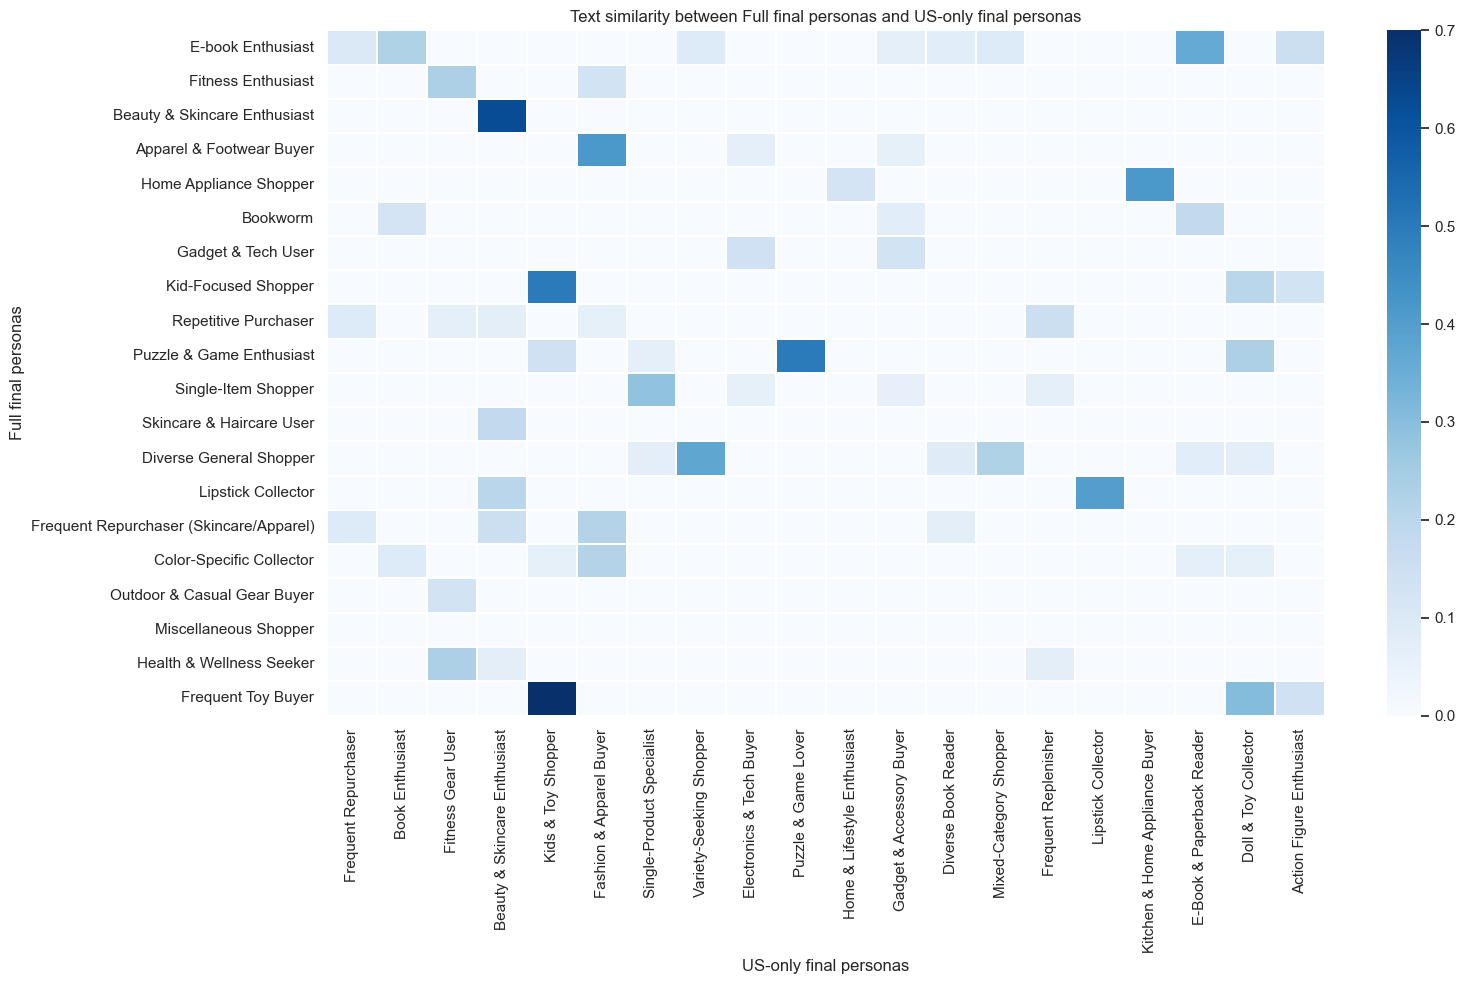

,Full persona,Best US-only match,similarity
19,Frequent Toy Buyer,Kids & Toy Shopper,0.700000
2,Beauty & Skincare Enthusiast,Beauty & Skincare Enthusiast,0.625000
9,Puzzle & Game Enthusiast,Puzzle & Game Lover,0.500000
7,Kid-Focused Shopper,Kids & Toy Shopper,0.500000
3,Apparel & Footwear Buyer,Fashion & Apparel Buyer,0.416667
4,Home Appliance Shopper,Kitchen & Home Appliance Buyer,0.416667
13,Lipstick Collector,Lipstick Collector,0.400000
12,Diverse General Shopper,Variety-Seeking Shopper,0.375000
0,E-book Enthusiast,E-Book & Paperback Reader,0.363636
10,Single-Item Shopper,Single-Product Specialist,0.285714


In [9]:
STOPWORDS = {
    'the', 'and', 'or', 'a', 'an', 'of', 'for', 'to', 'in', 'with', 'buys', 'buy', 'purchases',
    'purchase', 'multiple', 'often', 'items', 'item', 'products', 'product', 'user', 'shopper',
    'buyer', 'enthusiast', 'collector', 'frequent', 'frequently'
}


def tokens(text):
    words = re.findall(r'[a-z0-9]+', clean_text(text).lower())
    return {w for w in words if w not in STOPWORDS and len(w) > 2}

full_final = final_df[final_df['dataset'] == 'Full'].sort_values('rank').reset_index(drop=True)
us_final = final_df[final_df['dataset'] == 'US-only'].sort_values('rank').reset_index(drop=True)

sim = np.zeros((len(full_final), len(us_final)))
for i, ft in enumerate(full_final['text']):
    a = tokens(ft)
    for j, ut in enumerate(us_final['text']):
        b = tokens(ut)
        sim[i, j] = len(a & b) / len(a | b) if a | b else 0

sim_df = pd.DataFrame(sim, index=full_final['name'], columns=us_final['name'])

plt.figure(figsize=(16, 10))
sns.heatmap(sim_df, cmap='Blues', vmin=0, vmax=max(0.6, sim_df.values.max()), linewidths=0.2)
plt.title('Text similarity between Full final personas and US-only final personas')
plt.xlabel('US-only final personas')
plt.ylabel('Full final personas')
plt.tight_layout()
plt.show()

matches = []
for i, row in sim_df.iterrows():
    best = row.idxmax()
    matches.append({'Full persona': i, 'Best US-only match': best, 'similarity': row.max()})
match_df = pd.DataFrame(matches).sort_values('similarity', ascending=False)
match_df

## Review Flags

수동 정제를 위해 아래 기준으로 flag를 붙인다.

- `broad_or_misc`: 너무 넓은 general persona
- `color_artifact`: 합성 색상 토큰에 과하게 의존할 가능성
- `repeat_or_single`: 행동 패턴 persona라 카테고리 persona와 중복될 가능성
- `dense_group`: 같은 macro group이 final 20개 안에 3개 이상 존재

In [10]:
def has_pattern(text, pattern):
    return bool(re.search(pattern, clean_text(text).lower()))

final_review = final_df[['dataset', 'rank', 'name', 'macro_group', 'definition', 'text']].copy()
final_review['broad_or_misc'] = final_review['text'].map(lambda x: has_pattern(x, r'miscellaneous|diverse|mixed|variety|general|unrelated'))
final_review['color_artifact'] = final_review['text'].map(lambda x: has_pattern(x, r'color|shade|colour'))
final_review['repeat_or_single'] = final_review['text'].map(lambda x: has_pattern(x, r'repeat|repurchas|replenish|single|minimalist|specialist'))

group_size = final_review.groupby(['dataset', 'macro_group'])['name'].transform('count')
final_review['dense_group'] = group_size >= 3
final_review['review_flags'] = final_review.apply(
    lambda r: ', '.join([
        flag for flag in ['broad_or_misc', 'color_artifact', 'repeat_or_single', 'dense_group']
        if bool(r[flag])
    ]),
    axis=1,
)

review_cols = ['dataset', 'rank', 'name', 'macro_group', 'definition', 'review_flags']
final_review[review_cols].sort_values(['dataset', 'rank'])

,dataset,rank,name,macro_group,definition,review_flags
960,Full,1,E-book Enthusiast,Books,Purchases multiple e-books (often in bulk or across genres) with minimal other products.,dense_group
961,Full,2,Fitness Enthusiast,Fashion/Apparel,"Buys fitness gear (dumbbells, yoga mats, sneakers) and apparel for workouts.",dense_group
962,Full,3,Beauty & Skincare Enthusiast,Beauty/Skincare,"Purchases 2+ beauty items (lipsticks, moisturizers, serums, shampoos).",dense_group
963,Full,4,Apparel & Footwear Buyer,Fashion/Apparel,"Buys clothing (hoodies, jeans, sneakers, dresses) and accessories.",dense_group
964,Full,5,Home Appliance Shopper,Home/Kitchen,"Purchases kitchen or cleaning appliances (air fryers, vacuums, blenders).",
965,Full,6,Bookworm,Books,"Frequently buys e-books, hardcovers, or paperbacks (often in bulk).",dense_group
966,Full,7,Gadget & Tech User,Electronics/Tech,"Purchases electronics (monitors, mice, keyboards, webcams) for upgrades.",
967,Full,8,Kid-Focused Shopper,Toys/Games,"Buys toys (dolls, action figures, building blocks) for children.",dense_group
968,Full,9,Repetitive Purchaser,Beauty/Skincare,"Repurchases the same product (e.g., sneakers, moisturizers, water bottles).","repeat_or_single, dense_group"
969,Full,10,Puzzle & Game Enthusiast,Toys/Games,"Purchases puzzles, board games, or building blocks.",dense_group


In [11]:
flag_counts = (
    final_review.assign(flag_count=lambda d: d['review_flags'].ne('').astype(int))
    .groupby('dataset')
    .agg(
        final_personas=('name', 'count'),
        flagged_personas=('flag_count', 'sum'),
        color_artifacts=('color_artifact', 'sum'),
        broad_or_misc=('broad_or_misc', 'sum'),
        repeat_or_single=('repeat_or_single', 'sum'),
        dense_group=('dense_group', 'sum'),
    )
)
flag_counts

,final_personas,flagged_personas,color_artifacts,broad_or_misc,repeat_or_single,dense_group
dataset,,,,,,
Full,20,17,2,2,3,15
US-only,20,15,3,4,4,10


## Initial Interpretation

아래 셀은 위 EDA를 바탕으로 빠른 해석 문장을 생성한다. 최종 보고서에는 labeling 결과 분포를 추가한 뒤 업데이트한다.

In [12]:
def top_groups(dataset, n=3):
    s = (
        final_review[final_review['dataset'] == dataset]
        .groupby('macro_group')
        .size()
        .sort_values(ascending=False)
        .head(n)
    )
    return ', '.join([f'{idx}({val})' for idx, val in s.items()])

for dataset in ['Full', 'US-only']:
    print(f'{dataset} final top groups:', top_groups(dataset))
    flags = final_review[(final_review['dataset'] == dataset) & (final_review['review_flags'] != '')]
    print(f'{dataset} flagged personas:', len(flags), '/ 20')
    display(flags[review_cols])

print('Key caution: Full-vs-US country effect should be judged with labeling distributions under the same refined taxonomy, not by comparing two independently generated taxonomies only.')

Full final top groups: Beauty/Skincare(6), Books(3), Fashion/Apparel(3)
Full flagged personas: 17 / 20


,dataset,rank,name,macro_group,definition,review_flags
960,Full,1,E-book Enthusiast,Books,Purchases multiple e-books (often in bulk or across genres) with minimal other products.,dense_group
961,Full,2,Fitness Enthusiast,Fashion/Apparel,"Buys fitness gear (dumbbells, yoga mats, sneakers) and apparel for workouts.",dense_group
962,Full,3,Beauty & Skincare Enthusiast,Beauty/Skincare,"Purchases 2+ beauty items (lipsticks, moisturizers, serums, shampoos).",dense_group
963,Full,4,Apparel & Footwear Buyer,Fashion/Apparel,"Buys clothing (hoodies, jeans, sneakers, dresses) and accessories.",dense_group
965,Full,6,Bookworm,Books,"Frequently buys e-books, hardcovers, or paperbacks (often in bulk).",dense_group
967,Full,8,Kid-Focused Shopper,Toys/Games,"Buys toys (dolls, action figures, building blocks) for children.",dense_group
968,Full,9,Repetitive Purchaser,Beauty/Skincare,"Repurchases the same product (e.g., sneakers, moisturizers, water bottles).","repeat_or_single, dense_group"
969,Full,10,Puzzle & Game Enthusiast,Toys/Games,"Purchases puzzles, board games, or building blocks.",dense_group
970,Full,11,Single-Item Shopper,Fashion/Apparel,"Focuses on one unique product per transaction (e.g., SSD, hoodie, lamp).","repeat_or_single, dense_group"
971,Full,12,Skincare & Haircare User,Beauty/Skincare,"Buys sunscreens, shampoos, serums, or conditioners.",dense_group


US-only final top groups: Toys/Games(4), Beauty/Skincare(3), Books(3)
US-only flagged personas: 15 / 20


,dataset,rank,name,macro_group,definition,review_flags
1940,US-only,1,Frequent Repurchaser,Repeat/Single,"Buys the same item 3+ times, with 0-2 other items.",repeat_or_single
1941,US-only,2,Book Enthusiast,Books,Frequently purchases multiple hardcover/paperback books.,dense_group
1943,US-only,4,Beauty & Skincare Enthusiast,Beauty/Skincare,"Buys cosmetics (lipsticks) and skincare (serums, moisturizers, sunscreen).",dense_group
1944,US-only,5,Kids & Toy Shopper,Toys/Games,"Purchases toys (building blocks, dolls, action figures, plush toys).",dense_group
1945,US-only,6,Fashion & Apparel Buyer,Fashion/Apparel,"Buys clothing (dresses, t-shirts, jeans, sneakers) in varied colors.",color_artifact
1946,US-only,7,Single-Product Specialist,Fashion/Apparel,"Purchases only one unique product (e.g., lamp, webcam, dress, or puzzle).",repeat_or_single
1947,US-only,8,Variety-Seeking Shopper,Mixed/General,Buys 4-7+ diverse products across categories.,broad_or_misc
1949,US-only,10,Puzzle & Game Lover,Toys/Games,"Buys puzzles, board games, or similar leisure items.",dense_group
1952,US-only,13,Diverse Book Reader,Books,"Buys multiple paperback or e-book titles, sometimes with repeats.","broad_or_misc, repeat_or_single, dense_group"
1953,US-only,14,Mixed-Category Shopper,Mixed/General,Purchases 3+ items across 3+ distinct categories.,broad_or_misc


Key caution: Full-vs-US country effect should be judged with labeling distributions under the same refined taxonomy, not by comparing two independently generated taxonomies only.
